In [1]:
import torch
from torch.func import hessian, vmap, jacrev
import matplotlib.pyplot as plt
import numpy as np

from flash_ansr import FlashANSR, SoftmaxSamplingConfig, install_model, get_path, ConvergenceError
from flash_ansr.expressions.compilation import codify
from flash_ansr.expressions.token_ops import identify_constants, flatten_nested_list

from simplipy import SimpliPyEngine
from simplipy.operators import cos

In [2]:
from flash_ansr import FlashANSRDataset, get_path

In [3]:
dataset = FlashANSRDataset.from_config(get_path('configs', 'v23.0-120M', 'dataset_train.yaml'))

Compiling Skeletons: 100%|██████████| 107/107 [00:00<00:00, 21938.24it/s]


In [4]:
fisher_metrics = []
hessian_metrics = []
expression_lengths = []
for batch in dataset.iterate(steps=100, batch_size=128, include_metrics=None, verbose=True):
    batch = dataset.collate(batch)
    # fisher_metrics.extend([batch["fisher_metric"][i].item() for i in range(len(batch["fisher_metric"]))])
    # hessian_metrics.extend([batch["curvature_metric"][i].item() for i in range(len(batch["curvature_metric"]))])
    expression_lengths.extend([len(batch["skeleton"][i]) for i in range(len(batch["skeleton"]))])

Generating Batches: 100%|██████████| 100/100 [00:09<00:00, 10.50it/s]


/tmp/ipykernel_22651/2810131643.py:2: RuntimeWarning: divide by zero encountered in log10
  axes[0].hist(np.log10(fisher_metrics), bins=np.linspace(-10, 40, 50), color='tab:blue', alpha=0.7)
/tmp/ipykernel_22651/2810131643.py:4: RuntimeWarning: divide by zero encountered in log10
  axes[1].hist(np.log10(hessian_metrics), bins=np.linspace(-10, 20, 50), color='tab:orange', alpha=0.7)


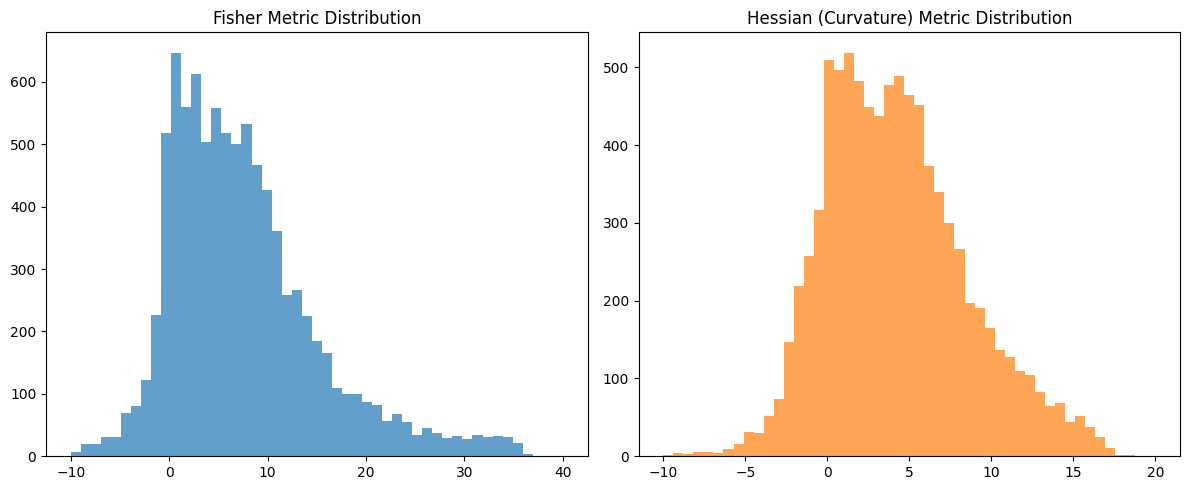

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(np.log10(fisher_metrics), bins=np.linspace(-10, 40, 50), color='tab:blue', alpha=0.7)
axes[0].set_title('Fisher Metric Distribution')
axes[1].hist(np.log10(hessian_metrics), bins=np.linspace(-10, 20, 50), color='tab:orange', alpha=0.7)
axes[1].set_title('Hessian (Curvature) Metric Distribution')
plt.tight_layout()

In [11]:
len(fisher_metrics), len(hessian_metrics), len(expression_lengths)

(12801, 12800, 12800)

/tmp/ipykernel_22651/993326118.py:2: RuntimeWarning: divide by zero encountered in log10
  ax.hist2d(np.log10(fisher_metrics), np.log10(hessian_metrics), bins=(np.linspace(-10, 40, 50), np.linspace(-10, 20, 50)));


ValueError: x and y must have the same length.

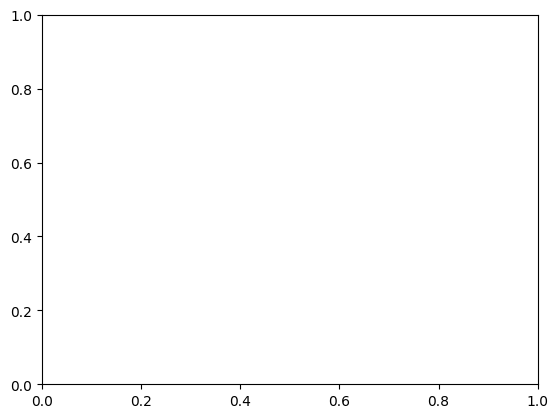

In [6]:
fig, ax = plt.subplots()
ax.hist2d(np.log10(fisher_metrics), np.log10(hessian_metrics), bins=(np.linspace(-10, 40, 50), np.linspace(-10, 20, 50)));

/tmp/ipykernel_9105/1752158668.py:2: RuntimeWarning: divide by zero encountered in log10
  ax.hist2d(expression_lengths, np.log10(fisher_metrics), bins=(np.linspace(0, 40, 40), np.linspace(-10, 40, 50)));


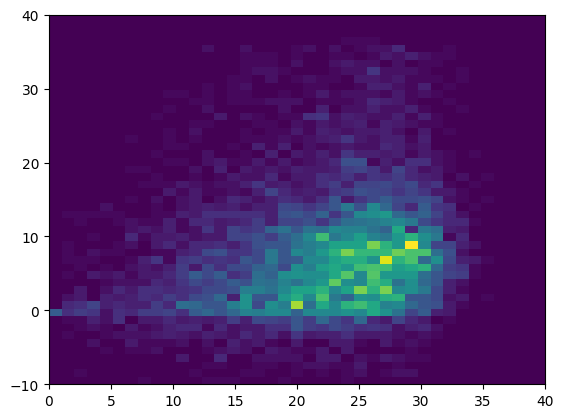

In [15]:
fig, ax = plt.subplots()
ax.hist2d(expression_lengths, np.log10(fisher_metrics), bins=(np.linspace(0, 40, 40), np.linspace(-10, 40, 50)));

/tmp/ipykernel_9105/2327708584.py:2: RuntimeWarning: divide by zero encountered in log10
  ax.hist2d(expression_lengths, np.log10(hessian_metrics), bins=(np.linspace(0, 40, 40), np.linspace(-10, 20, 50)));


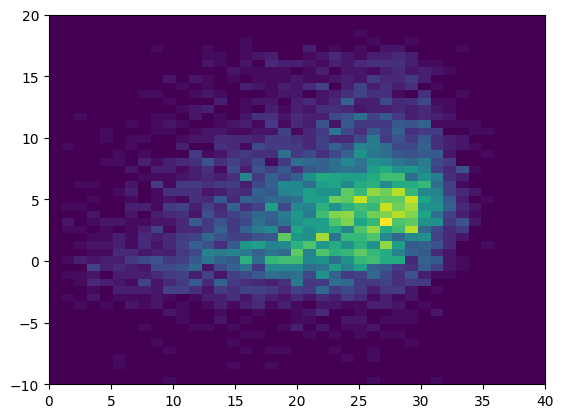

In [ ]:
fig, ax = plt.subplots()
ax.hist2d(expression_lengths, np.log10(hessian_metrics), bins=(np.linspace(0, 40, 40), np.linspace(-10, 20, 50)));

In [99]:
def x_prior(n, input_dim):
    # Sample bounds a and b from cauchy in each dimension
    a = torch.distributions.Cauchy(0, 1).sample((input_dim, ))
    b = torch.distributions.Cauchy(0, 1).sample((input_dim,))
    low = torch.min(a, b)
    high = torch.max(a, b)

    # Within a and b, sample uniformly
    return torch.distributions.Uniform(low, high).sample((n,))

def c_prior(n, input_dim):
    return torch.distributions.Cauchy(0, 1).sample((n, input_dim))

In [100]:
def get_curvature_metric(f, c_params, num_samples=1000):
    """
    Estimates the 'Total Curvature' (complexity) of f(.; c)
    by averaging the Hessian Frobenius norm over a standard domain.
    """
    hessian_fn = hessian(f, argnums=0)

    # Sample random inputs X from the prior
    input_dim = int(c_params.numel())
    X_batch = x_prior(num_samples, input_dim).to(c_params)

    # Use vmap to batch the hessian computation over the N samples
    # hessian_fn(x, c) returns 2x2 matrix. vmap adds batch dim -> (N, 2, 2)
    batch_hessian = vmap(hessian_fn, in_dims=(0, None))(X_batch, c_params)

    # Compute Frobenius norm for each sample: sqrt(sum(H_ij^2))
    curvature_norms = torch.norm(batch_hessian, p='fro', dim=(1, 2))

    # Return mean curvature
    return curvature_norms.mean().item()

def get_fisher_metric(f, c_params, num_samples=1000):
    """
    Estimates the Fisher information trace under a unit-variance Gaussian noise model,
    which reduces to the average squared gradient norm w.r.t. inputs.
    """
    grad_fn = jacrev(f, argnums=0)

    # Sample random inputs X from the prior
    input_dim = int(c_params.numel())
    X_batch = x_prior(num_samples, input_dim).to(c_params)

    # Batch gradients over samples -> (N, input_dim)
    batch_grad = vmap(grad_fn, in_dims=(0, None))(X_batch, c_params)

    # Trace of Fisher = ||grad||^2 for scalar output
    fisher_trace = torch.sum(batch_grad ** 2, dim=1)

    # Return mean Fisher trace
    return fisher_trace.mean().item()

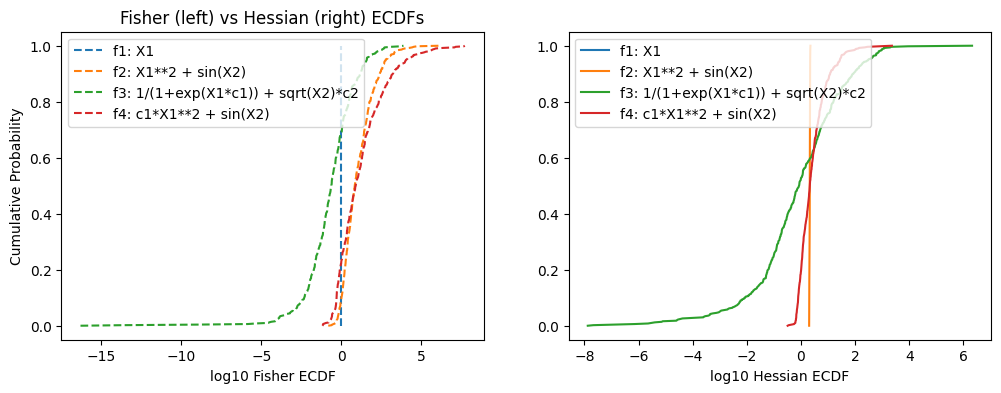

In [101]:
import math

# Functions expect x shape (..., 2) and c shape (2,)
def f1(x, c):
    return x[..., 0]

def f2(x, c):
    return x[..., 0] ** 2 + torch.sin(x[..., 1])

def f3(x, c):
    c1, c2 = c[0], c[1]
    x1 = x[..., 0]
    x2 = torch.clamp_min(x[..., 1], 0.0)
    return 1.0 / (1.0 + torch.exp(x1 * c1)) + torch.sqrt(x2) * c2

def f4(x, c):
    return c[0] * x[..., 0] ** 2 + cos(x[..., 1])

# Parameters
N = 512  # number of random input sets X
M = 512   # number of random constants c
input_dim = 2

# Sample M constants and evaluate metrics per function
c_samples = c_prior(M, input_dim)

hessian_results = {
    "f1: X1": [],
    "f2: X1**2 + sin(X2)": [],
    "f3: 1/(1+exp(X1*c1)) + sqrt(X2)*c2": [],
    "f4: c1*X1**2 + sin(X2)": [],
}
fisher_results = {name: [] for name in hessian_results}

for i in range(M):
    c_i = c_samples[i]
    hessian_results["f1: X1"].append(get_curvature_metric(f1, c_i, num_samples=N))
    hessian_results["f2: X1**2 + sin(X2)"].append(get_curvature_metric(f2, c_i, num_samples=N))
    hessian_results["f3: 1/(1+exp(X1*c1)) + sqrt(X2)*c2"].append(get_curvature_metric(f3, c_i, num_samples=N))
    hessian_results["f4: c1*X1**2 + sin(X2)"].append(get_curvature_metric(f4, c_i, num_samples=N))

    fisher_results["f1: X1"].append(get_fisher_metric(f1, c_i, num_samples=N))
    fisher_results["f2: X1**2 + sin(X2)"].append(get_fisher_metric(f2, c_i, num_samples=N))
    fisher_results["f3: 1/(1+exp(X1*c1)) + sqrt(X2)*c2"].append(get_fisher_metric(f3, c_i, num_samples=N))
    fisher_results["f4: c1*X1**2 + sin(X2)"].append(get_fisher_metric(f4, c_i, num_samples=N))



fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, vals in fisher_results.items():
    valid_vals = np.array(vals)
    valid_vals = valid_vals[np.isfinite(valid_vals)]
    valid_vals = valid_vals[valid_vals > 0]
    valid_vals = np.sort(valid_vals)
    sorted_vals = np.log10(valid_vals)
    axes[0].plot(sorted_vals, np.linspace(0, 1, len(valid_vals)), linestyle="--", label=name)

for name, vals in hessian_results.items():
    valid_vals = np.array(vals)
    valid_vals = valid_vals[np.isfinite(valid_vals)]
    valid_vals = valid_vals[valid_vals > 0]
    valid_vals = np.sort(valid_vals)
    sorted_vals = np.log10(valid_vals)
    axes[1].plot(sorted_vals, np.linspace(0, 1, len(valid_vals)), label=name)

axes[0].set_xlabel("log10 Fisher ECDF")
axes[1].set_xlabel("log10 Hessian ECDF")
axes[0].set_ylabel("Cumulative Probability")
axes[0].set_title("Fisher (left) vs Hessian (right) ECDFs")
axes[0].legend()
axes[1].legend()

In [89]:
%%timeit
get_fisher_metric(f3, c_samples[0], num_samples=1000)

593 μs ± 22 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [90]:
%%timeit
get_curvature_metric(f3, c_samples[0], num_samples=1000)

2.34 ms ± 90.7 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [91]:
from flash_ansr import FlashANSRDataset, get_path

In [92]:
dataset = FlashANSRDataset.from_config(get_path('configs', 'v23.0-120M', 'dataset_train.yaml'))

Compiling Skeletons: 100%|██████████| 107/107 [00:00<00:00, 23037.35it/s]


In [96]:
engine = SimpliPyEngine.load('dev_7-3')